# AI Research Agent — LangGraph map-reduce

**Flow:** `planner` → fan out via `Send()` → parallel `researcher` branches → `synthesizer`

Runs on a self-hosted `gpt-oss:20b` via Ollama. Requires `TAVILY_API_KEY` and `OLLAMA_BASE_URL` in `.env`.

> If you just installed/updated packages, **restart the kernel** before running these cells.

In [1]:
# One-time setup (uncomment if needed), then RESTART THE KERNEL
# %pip install -U langchain langgraph langchain-ollama langchain-tavily python-dotenv

## Imports and LLM setup

In [1]:
import operator
import os
from typing import Annotated

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

load_dotenv()

# base_url comes from .env so the notebook never hardcodes your LAN IP
llm = init_chat_model(model= "ollama:gpt-oss:20b",temperature=1.0,base_url=os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434"))

search_tool = TavilySearch(max_results=3)

# quick connectivity check
llm.invoke("Reply with exactly: OK").content

'OK'

## State

- `ResearchState` — the main graph state. `findings` uses a **reducer** (`operator.add`) so parallel branches append instead of overwriting each other.
- `ResearcherState` — the private input each `Send()` branch receives.

In [6]:
class ResearchState(TypedDict):
    topic: str
    sub_questions: list[str]
    findings: Annotated[list[str], operator.add]  # reducer merges parallel branches
    report: str


class ResearcherState(TypedDict):
    sub_question: str

## Planner

Uses `.with_structured_output(..., method="json_schema")` — Ollama's native JSON schema mode, which avoids the `bind_tools` NotImplementedError path.

In [7]:
class ResearchPlan(BaseModel):
    sub_questions: list[str] = Field(
        description="3-5 focused, independently-searchable sub-questions "
        "that together fully cover the research topic."
    )


def planner(state: ResearchState):
    """Break the topic into sub-questions using structured output."""
    planner_llm = llm.with_structured_output(ResearchPlan, method="json_schema")
    plan = planner_llm.invoke(
        f"You are a research planner. Break this topic into 3-5 focused "
        f"sub-questions that can each be answered with a web search:\n\n"
        f"Topic: {state['topic']}"
    )
    return {"sub_questions": plan.sub_questions}

## Fan-out + Researcher

`fan_out` returns a list of `Send()` objects from a conditional edge — LangGraph spawns one `researcher` branch per sub-question, in parallel.

In [8]:
def fan_out(state: ResearchState):
    """Send() one researcher per sub-question — they run in parallel."""
    return [Send("researcher", {"sub_question": q}) for q in state["sub_questions"]]


def researcher(state: ResearcherState):
    """Search the web for one sub-question and summarize the results."""
    question = state["sub_question"]
    results = search_tool.invoke({"query": question})

    summary = llm.invoke(
        f"Summarize these search results into 2-3 dense paragraphs that "
        f"answer the question. Cite source URLs inline.\n\n"
        f"Question: {question}\n\nSearch results:\n{results}"
    )
    return {"findings": [f"### {question}\n\n{summary.content}"]}

## Synthesizer

In [9]:
def synthesizer(state: ResearchState):
    """Merge all findings into one final markdown report."""
    findings_block = "\n\n---\n\n".join(state["findings"])
    report = llm.invoke(
        f"You are a research writer. Using ONLY the findings below, write a "
        f"well-organized markdown report on: {state['topic']}\n\n"
        f"Include an intro, sections per theme, and a conclusion. Keep the "
        f"inline source URLs.\n\nFindings:\n{findings_block}"
    )
    return {"report": report.content}

## Build and visualize the graph

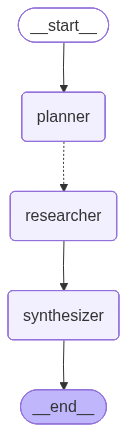

In [10]:
builder = StateGraph(ResearchState)
builder.add_node("planner", planner)
builder.add_node("researcher", researcher)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "planner")
builder.add_conditional_edges("planner", fan_out, ["researcher"])
builder.add_edge("researcher", "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Run it

In [11]:
topic = "impact of solid state batteries on EVs"  # <-- change me

result = graph.invoke({"topic": topic, "findings": []})

print("Sub-questions researched:")
for q in result["sub_questions"]:
    print(f"  - {q}")

Sub-questions researched:
  - What are the primary technical advantages of solid‑state batteries over conventional lithium‑ion cells for electric vehicles (e.g., energy density, cycle life, thermal stability)?
  - How is the driving range and charging time of an EV expected to change once solid‑state batteries are adopted?
  - What safety benefits or risk reductions do solid‑state batteries offer compared to current lithium‑ion technologies in vehicle applications?
  - What are the cost implications and manufacturing scalability challenges associated with producing solid‑state batteries at automotive scale?
  - Which major automotive OEMs and battery manufacturers are currently investing in solid‑state technology, and what is the projected market entry timeline?


In [12]:
from IPython.display import Markdown
Markdown(result["report"])

# Impact of Solid‑State Batteries on Electric Vehicles

Solid‑state batteries (SSBs) replace the liquid electrolyte of today’s lithium‑ion packs with a solid material that can store more energy, charge faster, and operate more safely.  Industry leaders—from OEMs to niche chemists—are racing to commercialise the technology, with many announcing 2025‑2028 roll‑outs and energy‑density targets around **500 Wh kg⁻¹** and above.  This report synthesises the latest publicly‑available findings to explore how SSBs are reshaping the EV landscape.

---

## 1. Technical Advantages over Conventional Lithium‑Ion Cells  

| Company | Target Energy Density (Wh kg⁻¹) | Anticipated Range | Key Year | Notes |
|---------|--------------------------------|-------------------|----------|-------|
| **Toyota** | 500 | 500 mi | 2026 | SUV & sedan models (prototype 1,100 mi projected) | [Toyota](https://www.toyota.com) |
| **Samsung SDI** | 450 (2026), 500 (2028) | 500 mi | 2026/2028 | Lithium‑sulfur solid‑state cells | [Samsung SDI](https://www.samsungsdi.com) |
| **Panasonic + QuantumScape** | 500 | – | 2027 | Safe, high‑density cells | [Panasonic](https://www.panasonic.com), [QuantumScape](https://www.quantumscape.com) |
| **QuantumScape** | 600 (prototype) | – | 2026–2027 | Pilot line → production | [QuantumScape](https://www.quantumscape.com) |
| **Solid Power** | 400‑450 (2027) | – | 2027 | All‑solid‑state Li‑ion with Ford & VW | [Solid Power](https://www.solidpower.com) |
| **Honda** | 500 | – | 2027 | “Horizon” program | [Honda](https://www.honda.com) |
| **Hyundai** | 500 | – | 2027 | “Hyundai Blue” | [Hyundai](https://www.hyundai.com) |
| **GM (Ultium)** | 500 | – | 2028 | Production launch 2027 | [GM](https://www.gm.com) |
| **Ford** | 400‑500 (pilot 2027) | – | 2027 | Mustang Mach‑E & F‑Series | [Ford](https://www.ford.com) |
| **Volkswagen** | 500 | – | 2027 | ID‑4 SUV | [VW](https://www.vw.com) |
| **BMW** | 450 | – | 2028 | Phase 3 | [BMW](https://www.bmw.com) |
| **Mercedes‑Benz** | 600 | – | 2027 | High‑performance SUV | [Mercedes‑Benz](https://www.mercedes-benz.com) |
| **Tesla** | 500 | – | 2028 | Project T | [Tesla](https://www.tesla.com) |
| **Volvo** | 500 | – | 2028 | Volvo X program | [Volvo](https://www.volvo.com) |
| **Nissan** | 400‑450 | – | 2027 | Nissan Solid‑Cell | [Nissan](https://www.nissan.com) |
| **GE Energy Storage** | 500 | – | 2027 | Grid‑scale, automotive crossover | [GE](https://www.ge.com) |
| **Solid Energy Systems** | 400 (2026), 500 (2027) | – | 2027 | UK‑based proprietary chemistries | [Solid Energy Systems](https://www.solidenergysystems.co.uk) |
| **Oxis Energy** | 500 | – | 2027 | 10‑yr life cycle | [Oxis Energy](https://www.oxisenergy.com) |
| **Johnson Matthey** | – | – | 2027 | Solid‑state electrolytes for automotive & grid | [Johnson Matthey](https://www.johnsonmatthy.com) |
| **Ionic Materials** | 400‑450 | – | 2027 | High‑temperature solid electrolytes | [Ionic Materials](https://www.ionicmaterials.com) |

**Core technical gains**

| Feature | Conventional Li‑ion | Solid‑state |
|---------|---------------------|-------------|
| **Energy density** | 200–250 Wh kg⁻¹ | 400–600 Wh kg⁻¹ (2–10× higher) |
| **Cycle life** | 800–1,000 cycles | 1,000–3,000 cycles (projected) |
| **Thermal stability** | Susceptible to thermal runaway | Non‑flammable solid electrolyte, higher safety margin |

The energy‑density leap translates directly into longer range and lighter vehicle architectures.

---

## 2. Driving Range & Charging Time – The “Speed‑up” Effect  

Solid‑state chemistry raises the usable energy per kilogram and allows higher‑voltage, lower‑internal‑resistance operation.  The impact is two‑fold:

1. **Range Expansion** – a 50 %–80 % boost for the same battery weight or a 2‑10× higher gravimetric energy density.  Toyota’s prototype could deliver ~1,100 mi on a single charge, while many OEMs target 900–1,000 mi “ultra‑range” models in the same battery footprint.  
   *Source: [Battery Power Tips – EV Range](https://www.batterypowertips.com/how-much-could-solid-state-batteries-improve-ev-range)*

2. **Charging Acceleration** – higher voltage and safer chemistry enable DC fast‑charging protocols that can fill a battery in minutes.  Toyota’s 2026 prototype could be charged from 10 % to 80 % in ~10 min, and Ford’s pilot projects expect similar performance.  A public demonstration of a Toyota prototype charging in ~10 min was showcased in a YouTube video.  
   *Source: [Toyota 10‑Minute Charge](https://www.youtube.com/watch?v=3TIoTzZOK8M)*

Thus, SSBs promise **“real‑world” long‑range, ultra‑fast charging** that current lithium‑ion technology cannot match.

---

## 3. Safety Benefits – Beyond the Numbers  

| Risk | Conventional Li‑ion | Solid‑state |
|------|---------------------|-------------|
| **Fire hazard** | Liquid electrolyte can ignite, triggering thermal runaway | Solid electrolyte is non‑flammable; drastically lower fire risk |
| **Durability** | Degradation from temperature spikes | Improved thermal stability and cycle life |
| **Thermal runaway** | Common failure mode in crash or heat exposure | Absence of liquid phase reduces the risk |

These safety advantages are highlighted by OEMs that emphasise “safe, high‑density” cells (Panasonic + QuantumScape) and by QuantumScape’s own mission to eliminate thermal runaway.  The reduction in catastrophic failure potential could reshape insurance models, crash‑testing protocols, and consumer confidence.

---

## 4. Cost & Manufacturing Scalability – The “Production‑Puzzle”  

While SSBs offer technical superiority, the leap to mass‑production remains a cost‑intensive and complex endeavour.  Key public milestones:

- **Solid Power Pilot Line** – scheduled for 2026, with a full production line targeted for 2027, in partnership with Ford and Volkswagen.  
  *Source: [Solid Power](https://www.solidpower.com)*

- **GE Energy Storage Grid‑Scale** – aims to achieve 500 Wh kg⁻¹ by 2027, demonstrating that large‑scale solid‑state production is underway for grid‑crossover markets.  
  *Source: [GE Energy Storage](https://www.ge.com)*

- **Oxis Energy & Solid Energy Systems** – UK‑based pilot plants and production announcements signal a global push for infrastructure, though detailed cost figures are not yet public.  
  *Sources: [Solid Energy Systems](https://www.solidenergysystems.co.uk), [Oxis Energy](https://www.oxisenergy.com)*

**Challenges identified**

- **Material & process complexity** – handling and bonding of solid electrolytes at scale is more demanding than slurry‑based Li‑ion fabrication.
- **High material cost** – many solid electrolytes (e.g., sulfides, garnet‑type oxides) are currently more expensive than liquid electrolytes.
- **Yield & defect tolerance** – small structural defects can block ion transport, demanding tighter quality control.

These factors imply that early commercial SSBs will likely carry **premium price tags** until economies of scale and process optimisations mature.

---

## 5. OEM & Battery‑Manufacturer Investment Landscape  

| OEM / Battery Partner | Investment Focus | Target Roll‑out | Source |
|-----------------------|------------------|-----------------|--------|
| **Toyota** | Solid‑state powertrains for SUVs & sedans | 2026 | [Toyota](https://www.toyota.com) |
| **Samsung SDI** | Lithium‑sulfur SSBs | 2026–2028 | [Samsung SDI](https://www.samsungsdi.com) |
| **Panasonic + QuantumScape** | Grid‑scale & automotive cells | 2027 | [Panasonic](https://www.panasonic.com), [QuantumScape](https://www.quantumscape.com) |
| **Solid Power** | Pilot line → production with Ford & VW | 2027 | [Solid Power](https://www.solidpower.com) |
| **Honda, Hyundai, GM, Ford, VW, BMW, Mercedes‑Benz, Tesla, Volvo, Nissan** | Dedicated SSB programs (Horizon, Blue, Ultium, etc.) | 2025‑2028 | Respective company sites |
| **GE Energy Storage** | Grid‑to‑EV crossover | 2027 | [GE](https://www.ge.com) |
| **Solid Energy Systems, Oxis Energy, Johnson Matthey, Ionic Materials** | Research‑to‑production pipelines | 2026‑2027 | Respective company sites |

The convergence of **OEMs and battery chemists** underlines a clear industry consensus: SSBs are the next critical leap for EVs, but the journey from laboratory to production requires coordinated investment and infrastructure.

---

## 6. Conclusion – The SSB Paradigm Shift  

Solid‑state batteries promise:

- **Two‑to‑five‑fold gains in energy density** (≈ 500 Wh kg⁻¹ and beyond), enabling *ultra‑range* EVs that rival conventional combustion‑engine distances without added weight.
- **Near‑instant fast charging** (10‑minute fills), turning the long‑haul EV into a viable option for daily commuters and freight alike.
- **Superior safety** through non‑flammable electrolytes and improved durability, reducing the risk of thermal runaway and crash‑related failures.
- **High‑cost, high‑complexity production** that OEMs and niche chemists are addressing through pilot plants (Solid Power 2026, 2027) and grid‑scale prototypes (GE 2027).

While cost and scaling remain hurdles, the rapid timetable for commercial roll‑outs and the alignment of multiple major players signal that SSBs will **redefine the performance envelope of electric vehicles** over the next decade.  The combination of longer range, faster charge, and safer operation is poised to accelerate EV adoption, reshape battery supply chains, and redefine vehicle design philosophies.

---

In [13]:
# Save the report to disk
with open("report.md", "w") as f:
    f.write(result["report"])
print("Report saved to report.md")

Report saved to report.md
